# Proyecto ABP: Laboratorio de Análisis Agropecuario
## Estrategia de Fidelización, Análisis de Demanda y Segmentación de Clientes
**Espacio Curricular:** Práctica Profesionalizante y Testeo de Software  
**Metodología:** CRISP-DM (Cross-Industry Standard Process for Data Mining)  
**Dataset Oficial:** `BD_lab_28-8-26.xlsx` (8.149 registros validados tras auditoría y limpieza)

---

## Fase 1: Comprensión del Negocio (Business Understanding)

### 1.1. Contexto Comercial y Problemática
El laboratorio opera tradicionalmente bajo un modelo comercial y operativo reactivo. Esta dinámica se traduce en una "ceguera operativa":
- Dependencia del flujo espontáneo de muestras que ingresan al laboratorio.
- Incapacidad para anticipar valles de baja actividad y cuellos de botella durante picos de cosecha.
- Riesgo de deserción silenciosa de clientes clave (churn agronómico), donde una cuenta deja de remitir muestras sin alerta previa.

### 1.2. Objetivos de Negocio y Correspondencia con Historias de Usuario (HUs)
Para resolver esta problemática se definieron 4 objetivos de negocio, alineados directamente con las Historias de Usuario del producto de software:

1. **Objetivo 1 $\leftrightarrow$ HU-01 (Fidelización y Retención de Clientes):**
   Analizar la demanda identificando clientes frecuentes por época del año y especie predominante, detectando cuentas en riesgo de deserción mediante el análisis de inactividad (corte comercial de 90 días) y desvíos estacionales.
2. **Objetivo 2 $\leftrightarrow$ HU-02 (Planificación Operativa y Capacidad del Laboratorio):**
   Identificar los intervalos críticos de demanda por cultivo para optimizar la asignación de analistas e insumos, analizando percentiles operativos P75 y P90 y asegurando la continuidad de servicio sin baches operativos.
3. **Objetivo 3 $\leftrightarrow$ Estacionalidad y Dinámica Temporal de Cultivos:**
   Estimar la tendencia y el patrón estacional comparativo entre los cultivos dominantes de la región: **Soja** (cosecha gruesa, picos otoño-invernales) y **Trigo** (cosecha fina, picos primaverales).
4. **Objetivo 4 $\leftrightarrow$ HU-03 (Segmentación RFM y Alerta de Fuga de Cartera):**
   Segmentar al 100% de los clientes mediante la metodología RFM (Recencia, Frecuencia, Valor Monetario) en 5 categorías oficiales (`Campeones`, `Fieles / Alto Valor`, `Potenciales`, `En Riesgo`, `Perdidos`), generando un **Listado de Contactos Urgentes** para mitigación activa de fuga.

### 1.3. Preguntas de Investigación e Hipótesis
1. **Concentración:** ¿Se cumple el principio de Pareto (80/20) tanto a nivel de especies como de clientes facturados?
2. **Estacionalidad:** ¿Cómo se desfasan los picos de demanda entre cultivos de gruesa y fina, y qué ventanas temporales demandan refuerzo técnico?
3. **Fuga de Cuentas:** ¿Cuántos clientes de alto valor histórico se encuentran actualmente inactivos y cuál es el impacto económico en riesgo?

---

## Fase 2: Comprensión de los Datos (Data Understanding)

En esta fase se ingesta el archivo fuente transaccional crudo, se realiza un Data Profiling exhaustivo y se audita la calidad técnica y consistencia lógica de las variables.

In [1]:
# 2.1 Importación de librerías y configuración del entorno analítico
import os
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Entorno analítico configurado correctamente.")

Entorno analítico configurado correctamente.


In [2]:
# 2.2 Localización e Ingesta del Dataset Crudo
# Soporta ejecución tanto desde la raíz del proyecto como desde la carpeta notebooks/
def get_data_paths():
    candidates_raw = [
        "data/raw/BD_lab_28-8-26.xlsx",
        "../data/raw/BD_lab_28-8-26.xlsx"
    ]
    candidates_processed = [
        "data/processed/cleaned_agro_data.csv",
        "../data/processed/cleaned_agro_data.csv"
    ]
    raw_path = next((p for p in candidates_raw if os.path.exists(p)), None)
    proc_path = candidates_processed[0] if os.path.exists("data") else candidates_processed[1]
    return raw_path, proc_path

raw_file_path, processed_file_path = get_data_paths()
print(f"Ruta de archivo crudo detectada: {raw_file_path}")

# Ingesta cruda desde Excel
df_raw = pd.read_excel(raw_file_path, sheet_name=0)
print(f"Dimensiones del dataset crudo: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas.")

Ruta de archivo crudo detectada: data/raw/BD_lab_28-8-26.xlsx


Dimensiones del dataset crudo: 8157 filas x 15 columnas.


In [3]:
# 2.3 Data Profiling: Diagnóstico de Completitud, Tipos y Cardinalidad
profiling_df = pd.DataFrame({
    'Tipo_Dato_Crudo': df_raw.dtypes,
    'Registros_No_Nulos': df_raw.notnull().sum(),
    'Valores_Nulos': df_raw.isnull().sum(),
    'Pct_Nulos (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(3),
    'Valores_Unicos': df_raw.nunique()
})

print("=== TABLA DE DATA PROFILING (DATASET CRUDO) ===")
display(profiling_df)

=== TABLA DE DATA PROFILING (DATASET CRUDO) ===


,Tipo_Dato_Crudo,Registros_No_Nulos,Valores_Nulos,Pct_Nulos (%),Valores_Unicos
Fecha Ing Muestra,object,8156,1,0.01,1011
Muestra,float64,8155,2,0.03,8150
Carta Camara,float64,8155,2,0.03,2127
Fecha de Certificacion,datetime64[us],8153,4,0.05,1038
Certificado,float64,8154,3,0.04,8150
Fecha Factura,datetime64[us],8155,2,0.03,532
PtoVta,float64,8155,2,0.03,1
Letra,str,8155,2,0.03,2
Numero Factura,float64,8155,2,0.03,2071
Id,float64,8155,2,0.03,361


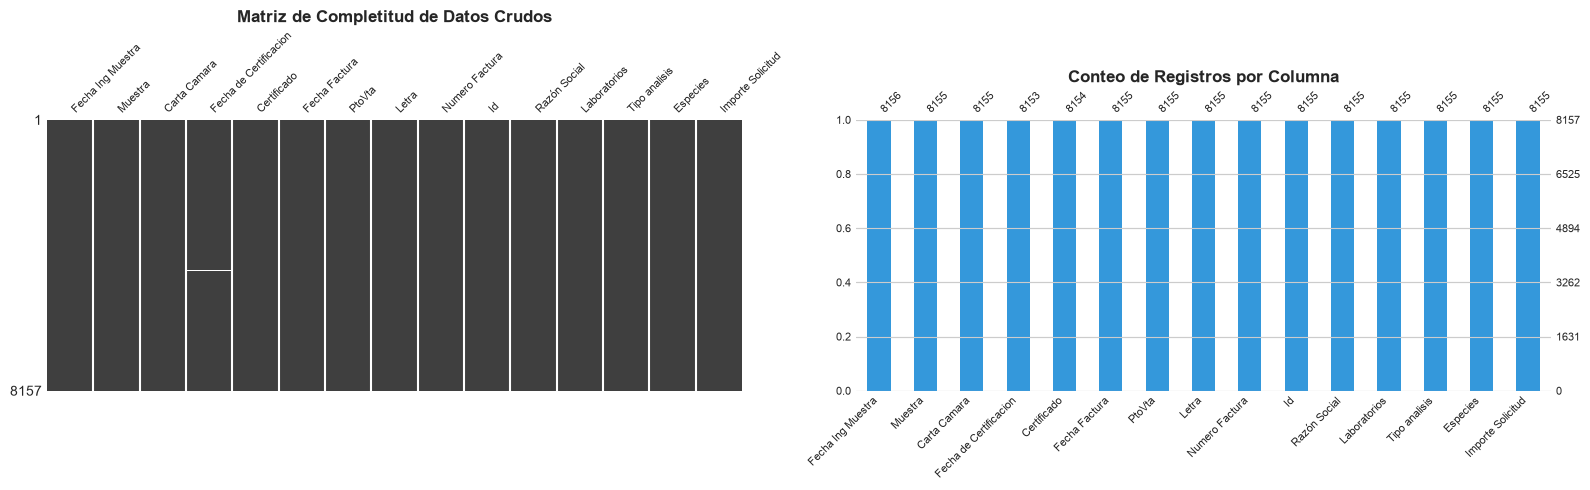

In [4]:
# 2.4 Visualización de Nulos con Missingno
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
msno.matrix(df_raw, ax=axes[0], sparkline=False, fontsize=8)
axes[0].set_title("Matriz de Completitud de Datos Crudos", fontsize=12, fontweight='bold')

msno.bar(df_raw, ax=axes[1], fontsize=8, color='#3498db')
axes[1].set_title("Conteo de Registros por Columna", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# 2.5 Auditoría Técnica de Calidad y Detección de Anomalías
# A. Filas con valores nulos (Pies de página y registros sin fecha de certificación)
filas_nulas = df_raw[df_raw.isnull().any(axis=1)]
print(f"Cantidad de filas con algún valor nulo: {len(filas_nulas)}")
display(filas_nulas[['Fecha Ing Muestra', 'Muestra', 'Fecha de Certificacion', 'Id', 'Especies', 'Importe Solicitud']])

# B. Detección de identificadores de muestra duplicados
duplicados_muestra = df_raw[df_raw['Muestra'].duplicated(keep=False) & df_raw['Muestra'].notnull()].sort_values('Muestra')
print(f"\nCantidad de registros con Muestra duplicada: {len(duplicados_muestra)} (corresponden a {duplicados_muestra['Muestra'].nunique()} muestras únicas)")
display(duplicados_muestra[['Fecha Ing Muestra', 'Muestra', 'Id', 'Raz\ufffdn Social' if 'Raz\ufffdn Social' in df_raw.columns else df_raw.columns[10], 'Especies', 'Importe Solicitud']])

Cantidad de filas con algún valor nulo: 4


,Fecha Ing Muestra,Muestra,Fecha de Certificacion,Id,Especies,Importe Solicitud
3261,2022-12-07 00:00:00,389801.00,NaT,392.00,Soja,7900.00
4538,2023-11-28 00:00:00,403626.00,NaT,5117.00,Grama Rhodes,39000.00
8155,NaN,NaN,NaT,NaN,NaN,NaN
8156,Filtros aplicados: \nArea es Semillas\nFecha F...,NaN,NaT,NaN,NaN,NaN



Cantidad de registros con Muestra duplicada: 10 (corresponden a 5 muestras únicas)


,Fecha Ing Muestra,Muestra,Id,Razón Social,Especies,Importe Solicitud
1905,2021-10-07 00:00:00,378689.00,4921.00,NN,Soja,3700.00
1906,2021-10-07 00:00:00,378689.00,4920.00,NN,Soja,3700.00
1908,2021-10-07 00:00:00,378691.00,4921.00,NN,Soja,4200.00
1909,2021-10-07 00:00:00,378691.00,4920.00,NN,Soja,4200.00
3261,2022-12-07 00:00:00,389801.00,392.00,NN,Soja,7900.00
3262,2022-12-07 00:00:00,389801.00,392.00,NN,Soja,7900.00
3643,2023-05-04 00:00:00,397018.00,4715.00,NN,Soja,19000.00
3644,2023-05-04 00:00:00,397018.00,4715.00,NN,Soja,19000.00
7881,2026-06-23 00:00:00,433933.00,3660.00,NN,Soja,77000.00
7882,2026-06-23 00:00:00,433933.00,6006.00,NN,Soja,77000.00


## Fase 3: Preparación de los Datos (Data Preparation)

En esta fase se implementa el pipeline de limpieza y estandarización para garantizar trazabilidad y reproducibilidad.
El criterio aplicado es:
1. **Normalización a `snake_case`:** Eliminación de tildes, caracteres especiales y mayúsculas en nombres de columnas.
2. **Depuración de nulos estructurales (`dropna()`):** Se eliminan 4 filas (2 filas vacías/totales al final y 2 muestras sin certificación válida), pasando de **8.157 a 8.153 filas**.
3. **Deduplicación por `id_muestra`:** Se eliminan 4 muestras repetidas conservando el primer registro (`keep='first'`), pasando de **8.153 a los 8.149 registros limpios oficiales**.
4. **Casting de tipos de datos:** Fechas a `datetime64[ns]`, identificadores a `int64`, importe monetario a `float64`.
5. **Generación de variable derivada `anio`** a partir del año de ingreso de la muestra.
6. **Sanitización de caracteres especiales** en nombres de cultivos y tipos de análisis.

In [6]:
# 3.1 Pipeline de Limpieza y Transformación reproducible
def to_snake_case(nombre_original):
    nombre = str(nombre_original).strip().lower()
    nombre = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', nombre)
    nombre = ''.join(c for c in unicodedata.normalize('NFD', nombre) if unicodedata.category(c) != 'Mn')
    nombre = re.sub(r'[^a-z0-9_]+', '_', nombre).strip('_')
    return nombre

# Copia de trabajo
df_limpio = df_raw.copy()

# Normalizar columnas
df_limpio.columns = [to_snake_case(col) for col in df_limpio.columns]

# 1. Eliminación de filas con valores nulos estructurales
filas_previas = len(df_limpio)
df_limpio = df_limpio.dropna().reset_index(drop=True)
print(f"Filas tras dropna(): {len(df_limpio)} (se descartaron {filas_previas - len(df_limpio)} filas)")

# 2. Eliminación de muestras duplicadas
filas_antes_dedup = len(df_limpio)
df_limpio = df_limpio.drop_duplicates(subset=['muestra'], keep='first').reset_index(drop=True)
print(f"Filas tras drop_duplicates(muestra): {len(df_limpio)} (se descartaron {filas_antes_dedup - len(df_limpio)} muestras duplicadas)")

# 3. Renombramiento estándar para el modelo analítico y la aplicación
df_limpio = df_limpio.rename(columns={
    'muestra': 'id_muestra',
    'id': 'id_cliente',
    'razon_social': 'razon_social'
})

# 4. Parseo y tipado estricto
date_columns = ['fecha_ing_muestra', 'fecha_de_certificacion', 'fecha_factura']
for col in date_columns:
    if col in df_limpio.columns:
        df_limpio[col] = pd.to_datetime(df_limpio[col], errors='coerce')

# Variable derivada: año de ingreso
df_limpio['anio'] = df_limpio['fecha_ing_muestra'].dt.year

# Enteros numéricos
for int_col in ['id_muestra', 'id_cliente', 'ptovta', 'numero_factura', 'certificado']:
    if int_col in df_limpio.columns:
        df_limpio[int_col] = pd.to_numeric(df_limpio[int_col], errors='coerce').fillna(0).astype(int)

# Importe monetario
df_limpio['importe_solicitud'] = pd.to_numeric(df_limpio['importe_solicitud'], errors='coerce').astype(float)

# Sanitización de caracteres en campos textuales
for txt_col in ['especies', 'tipo_analisis']:
    if txt_col in df_limpio.columns:
        df_limpio[txt_col] = (
            df_limpio[txt_col].astype(str)
            .str.replace('Maz', 'Maíz', regex=False)
            .str.replace('Man', 'Maní', regex=False)
            .str.replace('Algodn', 'Algodón', regex=False)
            .str.replace('Bsico', 'Básico', regex=False)
            .str.replace('Megatrmicas', 'Megatérmicas', regex=False)
        )

# Confirmación matemática del resultado esperado
assert len(df_limpio) == 8149, f"Error: Se esperaban 8.149 filas exactas, pero se obtuvieron {len(df_limpio)}"
assert df_limpio['id_muestra'].duplicated().sum() == 0, "Error: Existen muestras duplicadas"
assert df_limpio.isnull().sum().sum() == 0, "Error: Existen valores nulos en el dataset limpio"

print("\n>>> ¡VERIFICACIÓN EXITOSA!: Dataset limpio contiene exactamente 8.149 registros y 0 nulos.")

Filas tras dropna(): 8153 (se descartaron 4 filas)
Filas tras drop_duplicates(muestra): 8149 (se descartaron 4 muestras duplicadas)

>>> ¡VERIFICACIÓN EXITOSA!: Dataset limpio contiene exactamente 8.149 registros y 0 nulos.


In [7]:
# 3.2 Documentación de Variables del Dataset Limpio
df_resumen_limpio = pd.DataFrame({
    'Tipo_Dato': df_limpio.dtypes,
    'Registros_No_Nulos': df_limpio.notnull().sum(),
    'Valores_Nulos': df_limpio.isnull().sum(),
    'Valores_Unicos': df_limpio.nunique()
})

print("=== DICCIONARIO DE VARIABLES FINAL (8.149 REGISTROS) ===")
display(df_resumen_limpio)

=== DICCIONARIO DE VARIABLES FINAL (8.149 REGISTROS) ===


,Tipo_Dato,Registros_No_Nulos,Valores_Nulos,Valores_Unicos
fecha_ing_muestra,datetime64[us],8149,0,1010
id_muestra,int64,8149,0,8149
carta_camara,float64,8149,0,2127
fecha_de_certificacion,datetime64[us],8149,0,1038
certificado,int64,8149,0,8149
fecha_factura,datetime64[us],8149,0,530
ptovta,int64,8149,0,1
letra,str,8149,0,2
numero_factura,int64,8149,0,2067
id_cliente,int64,8149,0,360


In [8]:
# 3.3 Exportación del Dataset Limpio a CSV
os.makedirs(os.path.dirname(processed_file_path), exist_ok=True)
df_limpio.to_csv(processed_file_path, index=False)
print(f"Dataset exportado exitosamente en: {processed_file_path} ({len(df_limpio)} registros)")

Dataset exportado exitosamente en: data/processed/cleaned_agro_data.csv (8149 registros)


## Fase 4: Análisis Exploratorio de Datos (EDA) y Modelado

En esta fase se da respuesta rigurosa a cada uno de los 4 Objetivos de Negocio, integrando tanto los cálculos numéricos como las visualizaciones ejecutivas.

### 4.1. Objetivo 1 (HU-01): Demanda por Cliente, Estado de Actividad y Fidelización

El propósito es categorizar a los clientes según su actividad reciente para detectar oportunamente el riesgo de abandono.
Se define como fecha de referencia la última fecha transaccional registrada en el dataset (`2026-08-28`).
- **Clientes Activos:** Remitieron muestras en los últimos 90 días.
- **Clientes en Riesgo:** Sin remisiones en más de 90 días.

In [9]:
# 4.1.1 Análisis de Actividad Reciente y Segmentación de Cartera (Corte 90 días)
fecha_referencia = df_limpio['fecha_ing_muestra'].max()
print(f"Fecha máxima de referencia en el dataset: {fecha_referencia.strftime('%Y-%m-%d')}\n")

# Agrupación por cliente
clientes_actividad = df_limpio.groupby('id_cliente').agg(
    total_muestras=('id_muestra', 'count'),
    facturacion_total=('importe_solicitud', 'sum'),
    primera_muestra=('fecha_ing_muestra', 'min'),
    ultima_muestra=('fecha_ing_muestra', 'max')
).reset_index()

clientes_actividad['dias_inactivo'] = (fecha_referencia - clientes_actividad['ultima_muestra']).dt.days
clientes_actividad['antiguedad_dias'] = (fecha_referencia - clientes_actividad['primera_muestra']).dt.days
clientes_actividad['estado'] = np.where(clientes_actividad['dias_inactivo'] <= 90, 'Activo', 'En Riesgo')

resumen_estado = clientes_actividad['estado'].value_counts()
pct_riesgo = (resumen_estado.get('En Riesgo', 0) / len(clientes_actividad) * 100)

print(f"Total de clientes evaluados: {len(clientes_actividad)}")
print(f"Clientes Activos (<= 90 días): {resumen_estado.get('Activo', 0)}")
print(f"Clientes En Riesgo (> 90 días): {resumen_estado.get('En Riesgo', 0)} ({pct_riesgo:.1f}%)")

Fecha máxima de referencia en el dataset: 2026-08-28

Total de clientes evaluados: 360
Clientes Activos (<= 90 días): 35
Clientes En Riesgo (> 90 días): 325 (90.3%)


C:\Users\Juan\AppData\Local\Temp\ipykernel_34868\1569603598.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=resumen_estado.index, y=resumen_estado.values, palette=palette, ax=ax)


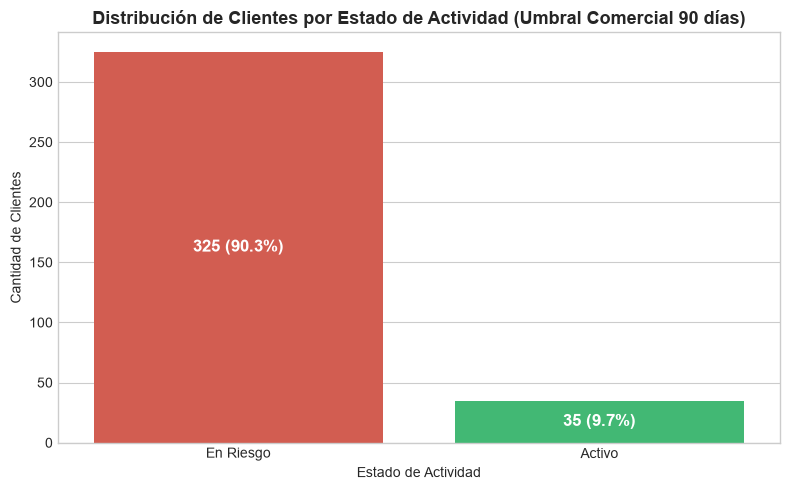

In [10]:
# 4.1.2 Visualización de Distribución de Clientes por Estado de Actividad
fig, ax = plt.subplots(figsize=(8, 5))
palette = {'Activo': '#2ecc71', 'En Riesgo': '#e74c3c'}
bars = sns.barplot(x=resumen_estado.index, y=resumen_estado.values, palette=palette, ax=ax)

for p in ax.patches:
    h = p.get_height()
    pct = (h / len(clientes_actividad)) * 100
    ax.annotate(f"{int(h)} ({pct:.1f}%)", (p.get_x() + p.get_width() / 2., h / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)

ax.set_title("Distribución de Clientes por Estado de Actividad (Umbral Comercial 90 días)", fontsize=13, fontweight='bold')
ax.set_ylabel("Cantidad de Clientes")
ax.set_xlabel("Estado de Actividad")
plt.tight_layout()
plt.show()

In [11]:
# 4.1.3 Top 20 Clientes por Volumen de Muestras y Cultivo Predominante
# Identificar para cada cliente su especie principal
especie_predominante = (
    df_limpio.groupby(['id_cliente', 'especies'])
    .size()
    .reset_index(name='conteo')
    .sort_values(['id_cliente', 'conteo'], ascending=[True, False])
    .drop_duplicates(subset=['id_cliente'])
    [['id_cliente', 'especies']]
    .rename(columns={'especies': 'cultivo_predominante'})
)

top20_ranking = (
    clientes_actividad.merge(especie_predominante, on='id_cliente', how='left')
    .sort_values('total_muestras', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

print("=== TOP 20 CLIENTES HISTÓRICOS POR VOLUMEN DE MUESTRAS ===")
display(top20_ranking[['id_cliente', 'cultivo_predominante', 'total_muestras', 'facturacion_total', 'dias_inactivo', 'estado']])

=== TOP 20 CLIENTES HISTÓRICOS POR VOLUMEN DE MUESTRAS ===


,id_cliente,cultivo_predominante,total_muestras,facturacion_total,dias_inactivo,estado
0,392,Soja,2204,62692050.00,15,Activo
1,522,Soja,488,23280500.00,44,Activo
2,104,Sorgo,452,14858150.00,30,Activo
3,2795,Soja,378,10361450.00,107,En Riesgo
4,4557,Soja,297,6176100.00,109,En Riesgo
5,62,Maíz,284,17281750.00,9,Activo
6,1328,Gatton Panic,269,9984200.00,10,Activo
7,25,Maníí,252,4885050.00,113,En Riesgo
8,9261,Soja,186,6502000.00,16,Activo
9,4237,Soja,164,744400.00,800,En Riesgo


### 4.2. Objetivo 2 (HU-02): Demanda por Cultivo e Intervalos Críticos de Capacidad

El objetivo es caracterizar la distribución del volumen analítico entre las distintas especies ensayadas y establecer umbrales de capacidad basados en percentiles (P75 y P90) para prever la demanda operativa del laboratorio.

In [12]:
# 4.2.1 Estadísticas Descriptivas de Volumen Mensual del Laboratorio
df_limpio['periodo_mensual'] = df_limpio['fecha_ing_muestra'].dt.to_period('M')
volumen_mensual = df_limpio.groupby('periodo_mensual').size().reset_index(name='cantidad_muestras')
volumen_mensual['periodo_str'] = volumen_mensual['periodo_mensual'].astype(str)

media_mensual = volumen_mensual['cantidad_muestras'].mean()
std_mensual = volumen_mensual['cantidad_muestras'].std()
p75 = volumen_mensual['cantidad_muestras'].quantile(0.75)
p90 = volumen_mensual['cantidad_muestras'].quantile(0.90)
max_mensual = volumen_mensual['cantidad_muestras'].max()
min_mensual = volumen_mensual['cantidad_muestras'].min()

print("=== ESTADÍSTICAS OPERATIVAS DE VOLUMEN MENSUAL (2020-2026) ===")
print(f"Meses analizados: {len(volumen_mensual)}")
print(f"Media mensual: {media_mensual:.1f} muestras/mes")
print(f"Desvío estándar: {std_mensual:.1f}")
print(f"Mínimo histórico: {min_mensual} muestras")
print(f"Percentil 75 (Alerta Operativa): {p75:.1f} muestras")
print(f"Percentil 90 (Capacidad Crítica): {p90:.1f} muestras")
print(f"Máximo histórico: {max_mensual} muestras")

=== ESTADÍSTICAS OPERATIVAS DE VOLUMEN MENSUAL (2020-2026) ===
Meses analizados: 74
Media mensual: 110.1 muestras/mes
Desvío estándar: 58.7
Mínimo histórico: 14 muestras
Percentil 75 (Alerta Operativa): 142.5 muestras
Percentil 90 (Capacidad Crítica): 191.0 muestras
Máximo histórico: 269 muestras


=== TOP 10 ESPECIES CONCENTRACIÓN DE DEMANDA ===


,especies,muestras,pct_individual,pct_acumulado
0,Soja,4709,57.79,57.79
1,Trigo,1159,14.22,72.01
2,Maíz,374,4.59,76.60
3,Gatton Panic,367,4.50,81.10
4,Sorgo,246,3.02,84.12
5,Maníí,217,2.66,86.78
6,Centeno,168,2.06,88.85
7,Garbanzo,107,1.31,90.16
8,Avena Blanca / Amarilla/ Byzantina,74,0.91,91.07
9,Alfalfa,72,0.88,91.95


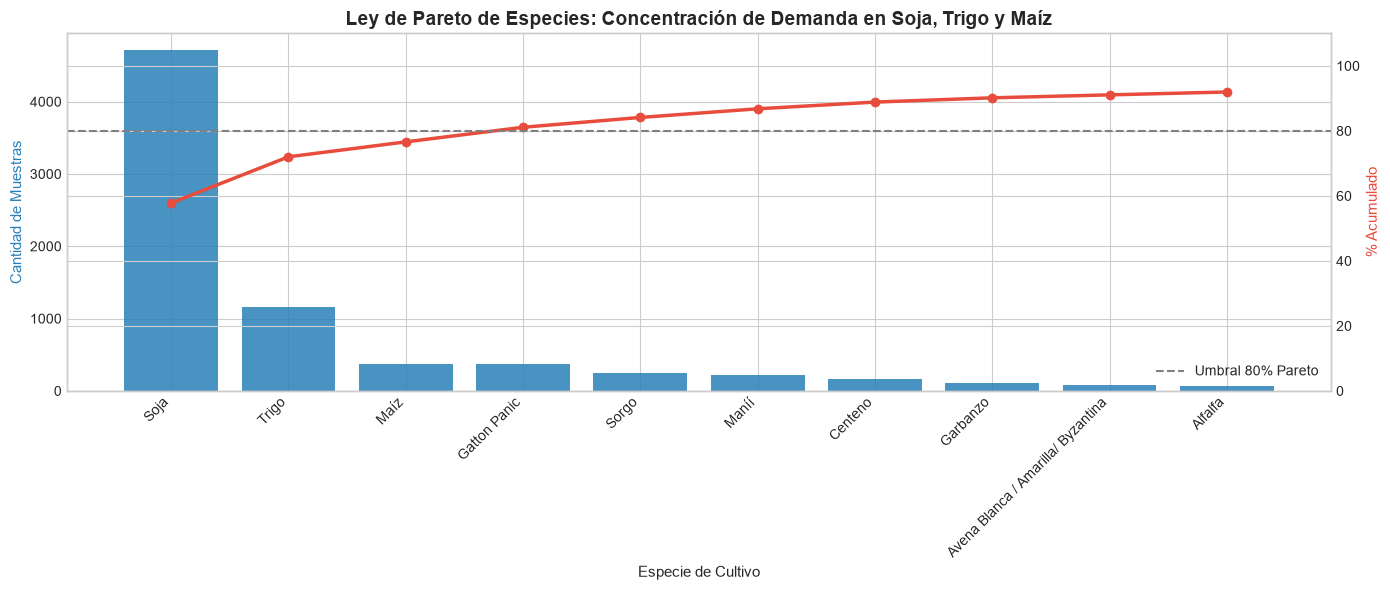

In [13]:
# 4.2.2 Análisis de Pareto de Especies Ensayadas (Principio 80/20)
pareto_especies = df_limpio['especies'].value_counts().reset_index()
pareto_especies.columns = ['especies', 'muestras']
pareto_especies['pct_individual'] = (pareto_especies['muestras'] / pareto_especies['muestras'].sum()) * 100
pareto_especies['pct_acumulado'] = pareto_especies['pct_individual'].cumsum()

print("=== TOP 10 ESPECIES CONCENTRACIÓN DE DEMANDA ===")
display(pareto_especies.head(10))

# Visualización Gráfica de Pareto de Especies
fig, ax1 = plt.subplots(figsize=(14, 6))
top_n_esp = 10
ax1.bar(pareto_especies['especies'].head(top_n_esp), pareto_especies['muestras'].head(top_n_esp), color='#2980b9', alpha=0.85)
ax1.set_ylabel("Cantidad de Muestras", color='#2980b9', fontsize=11)
ax1.set_xlabel("Especie de Cultivo", fontsize=11)
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(range(top_n_esp), pareto_especies['pct_acumulado'].head(top_n_esp), color='#e74c3c', marker='o', linewidth=2.5)
ax2.axhline(y=80, color='gray', linestyle='--', label='Umbral 80% Pareto')
ax2.set_ylabel("% Acumulado", color='#e74c3c', fontsize=11)
ax2.set_ylim(0, 110)
ax2.legend(loc='lower right')

plt.title("Ley de Pareto de Especies: Concentración de Demanda en Soja, Trigo y Maíz", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

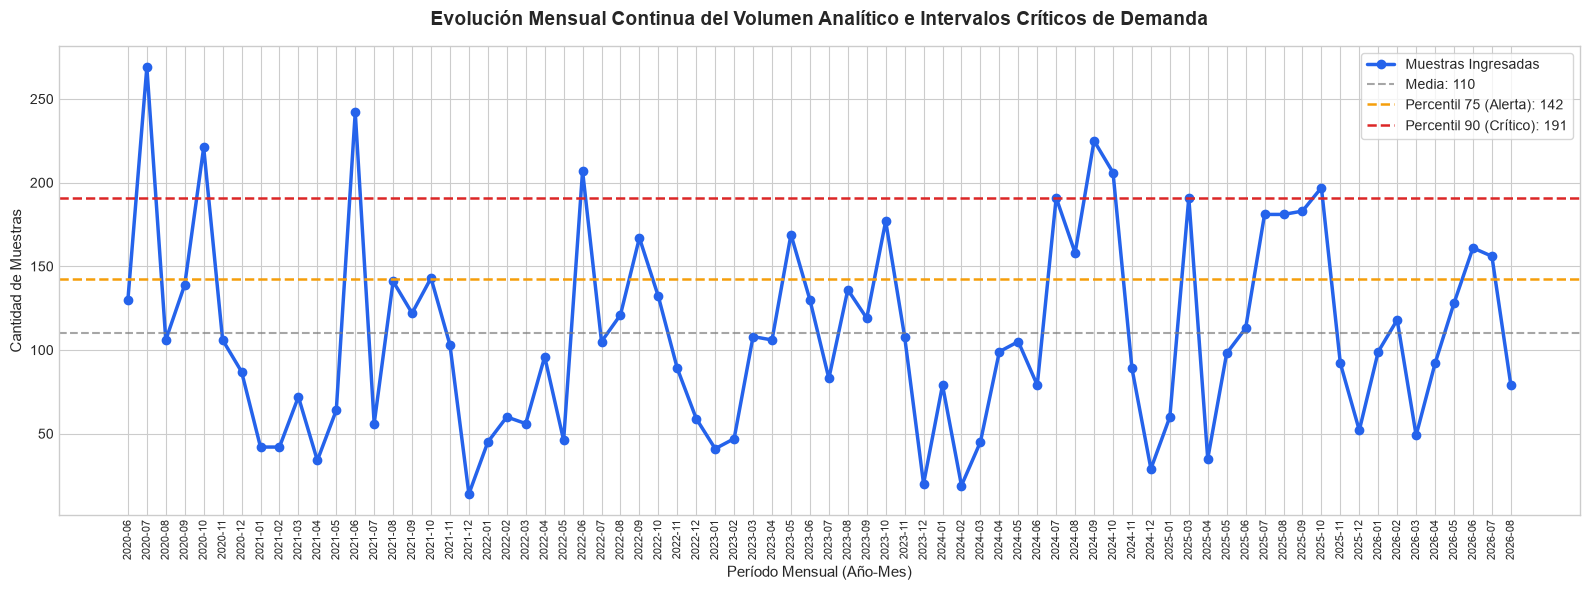

In [14]:
# 4.2.3 El 'Pulso' del Laboratorio: Evolución Temporal Continua vs Umbrales P75 y P90
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(volumen_mensual['periodo_str'], volumen_mensual['cantidad_muestras'], color='#2563eb', linewidth=2.5, marker='o', label='Muestras Ingresadas')

# Líneas de referencia operativa
ax.axhline(y=media_mensual, color='gray', linestyle='--', alpha=0.7, label=f"Media: {media_mensual:.0f}")
ax.axhline(y=p75, color='#f59e0b', linestyle='--', linewidth=1.8, label=f"Percentil 75 (Alerta): {p75:.0f}")
ax.axhline(y=p90, color='#dc2626', linestyle='--', linewidth=1.8, label=f"Percentil 90 (Crítico): {p90:.0f}")

ax.set_title("Evolución Mensual Continua del Volumen Analítico e Intervalos Críticos de Demanda", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Período Mensual (Año-Mes)", fontsize=11)
ax.set_ylabel("Cantidad de Muestras", fontsize=11)
plt.xticks(rotation=90, fontsize=8)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

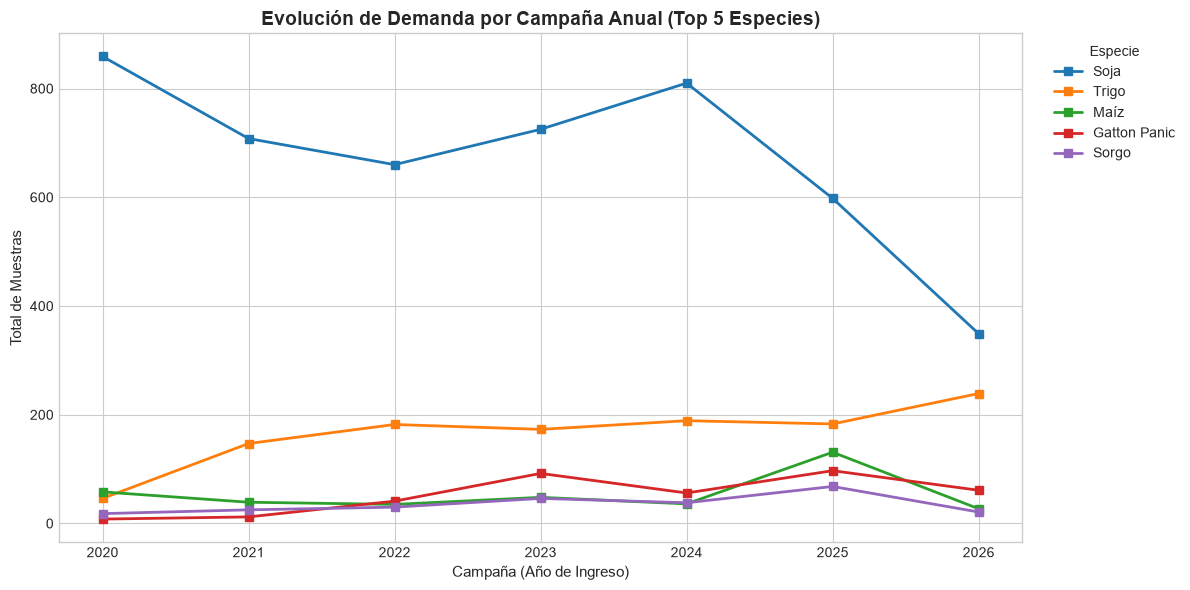

In [15]:
# 4.2.4 Evolución Histórica por Campaña (2020-2026) para las 5 Especies Principales
top5_global_esp = pareto_especies.head(5)['especies'].tolist()
df_top5_esp = df_limpio[df_limpio['especies'].isin(top5_global_esp)]

evolucion_anual_esp = df_top5_esp.groupby(['anio', 'especies']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
for esp in top5_global_esp:
    ax.plot(evolucion_anual_esp.index.astype(str), evolucion_anual_esp[esp], marker='s', linewidth=2, label=esp)

ax.set_title("Evolución de Demanda por Campaña Anual (Top 5 Especies)", fontsize=14, fontweight='bold')
ax.set_xlabel("Campaña (Año de Ingreso)", fontsize=11)
ax.set_ylabel("Total de Muestras", fontsize=11)
ax.legend(title="Especie", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.3. Objetivo 3: Dinámica Temporal y Estacionalidad de Cultivos Dominantes

El análisis se centra en la relación agronómica entre la cosecha gruesa (**Soja**) y la cosecha fina (**Trigo**), cuyos ciclos biológicos complementarios explican la estacionalidad del laboratorio.

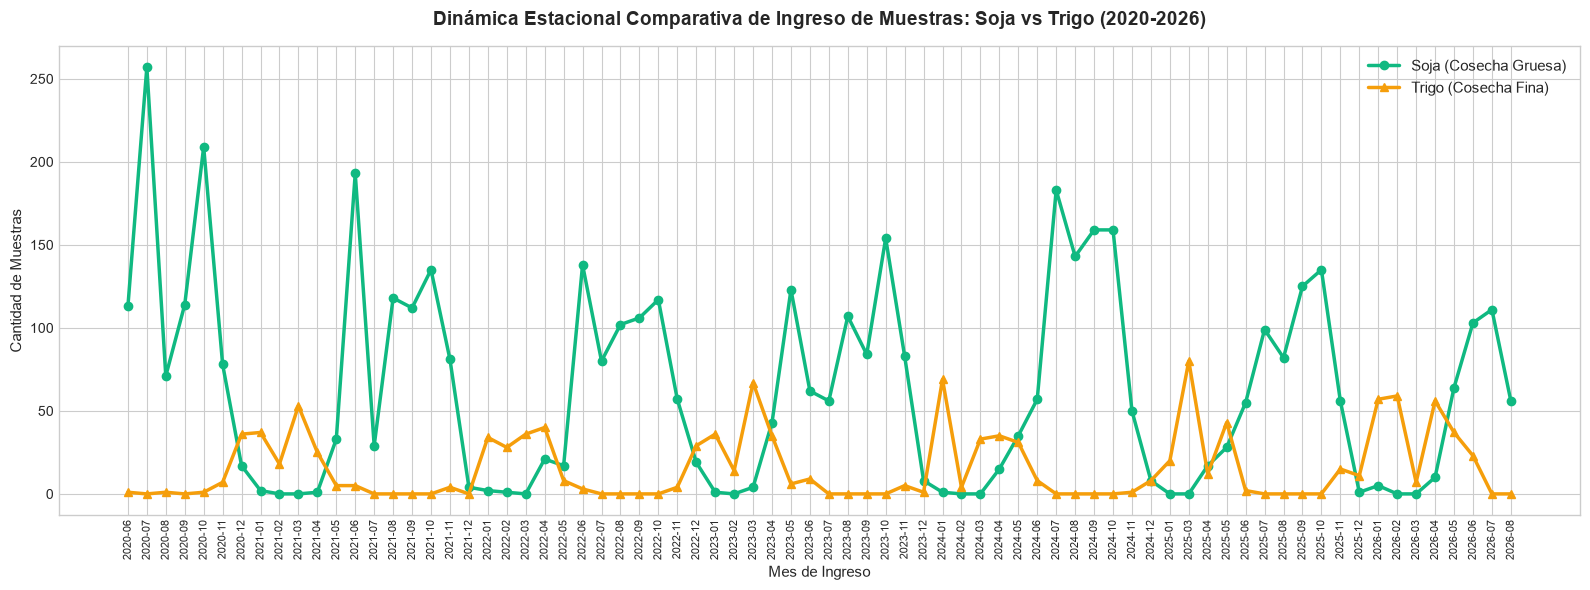

Interpretación Agronómica:
- Soja exhibe sus picos de muestreo en los meses posteriores a la cosecha gruesa (abril a agosto).
- Trigo presenta picos de análisis de calidad previos a la siembra y poscosecha fina (octubre a enero).


In [16]:
# 4.3.1 Comparativa Estacional Mensual: Soja (Cosecha Gruesa) vs Trigo (Cosecha Fina)
df_soja_trigo = df_limpio[df_limpio['especies'].str.lower().isin(['soja', 'trigo'])].copy()

# Agrupación por mes y cultivo
agrup_soja_trigo = (
    df_soja_trigo.groupby([df_soja_trigo['fecha_ing_muestra'].dt.to_period('M'), 'especies'])
    .size()
    .unstack(fill_value=0)
)
agrup_soja_trigo.index = agrup_soja_trigo.index.astype(str)

fig, ax = plt.subplots(figsize=(16, 6))
meses = agrup_soja_trigo.index

if 'Soja' in agrup_soja_trigo.columns:
    ax.plot(meses, agrup_soja_trigo['Soja'], color='#10b981', linewidth=2.5, marker='o', label='Soja (Cosecha Gruesa)')
if 'Trigo' in agrup_soja_trigo.columns:
    ax.plot(meses, agrup_soja_trigo['Trigo'], color='#f59e0b', linewidth=2.5, marker='^', label='Trigo (Cosecha Fina)')

ax.set_title("Dinámica Estacional Comparativa de Ingreso de Muestras: Soja vs Trigo (2020-2026)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Mes de Ingreso", fontsize=11)
ax.set_ylabel("Cantidad de Muestras", fontsize=11)
plt.xticks(rotation=90, fontsize=8)
ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

print("Interpretación Agronómica:")
print("- Soja exhibe sus picos de muestreo en los meses posteriores a la cosecha gruesa (abril a agosto).")
print("- Trigo presenta picos de análisis de calidad previos a la siembra y poscosecha fina (octubre a enero).")

### 4.4. Objetivo 4 (HU-03): Segmentación RFM y Alerta de Fuga de Cartera

Se aplica el modelo de segmentación RFM (Recencia, Frecuencia, Valor Monetario) evaluando al **100% de los clientes** de la cartera (sin exclusiones artificiales de ID > 50.000).
Se estructuran **5 Categorías Oficiales de Negocio**:
1. **Campeones:** Clientes de élite con máxima recencia, altísima frecuencia y facturación ($R \ge 4, F \ge 4, M \ge 4$).
2. **Fieles / Alto Valor:** Comportamiento regular de alto volumen ($R \ge 3$ y al menos $F \ge 3$ o $M \ge 3$).
3. **Potenciales:** Clientes recientes que aún operan con bajo volumen ($R \ge 3, F \le 2$).
4. **En Riesgo:** Cuentas históricamente valiosas cuya recencia cayó críticamente ($R \le 2$ y al menos $F \ge 4$ o $M \ge 4$).
5. **Perdidos:** Clientes con scores bajos en todas las dimensiones ($R \le 2, F \le 3, M \le 3$).

Total de clientes analizados: 360
Facturación acumulada total: $244,334,599.99
El 80% de la facturación histórica está concentrado en apenas 25 clientes (6.9% de la cartera).


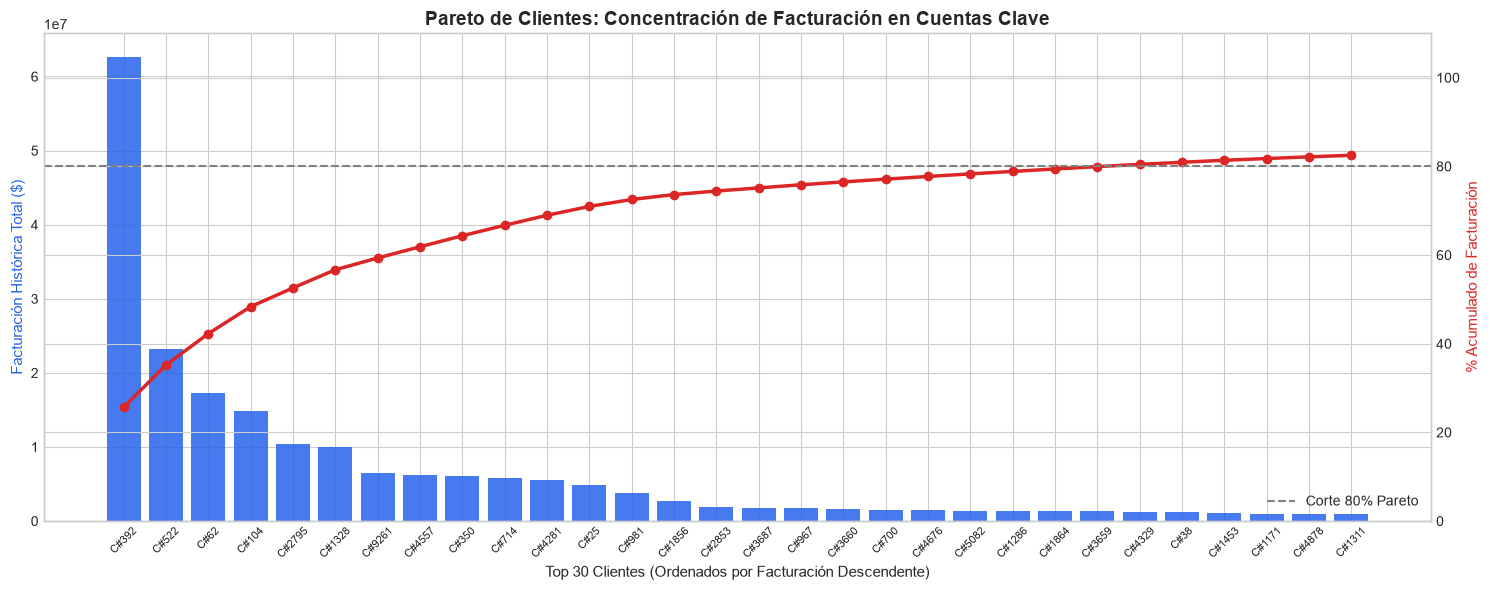

In [17]:
# 4.4.1 Concentración Económica: Pareto de Clientes en Facturación Acumulada
pareto_clientes = df_limpio.groupby('id_cliente')['importe_solicitud'].sum().sort_values(ascending=False)
pareto_clientes_pct = (pareto_clientes.cumsum() / pareto_clientes.sum()) * 100

top30_clientes = pareto_clientes.head(30)
top30_pct = pareto_clientes_pct.head(30)

clientes_80_pct = (pareto_clientes_pct <= 80).sum() + 1
pct_base_80 = (clientes_80_pct / len(pareto_clientes)) * 100

print(f"Total de clientes analizados: {len(pareto_clientes)}")
print(f"Facturación acumulada total: ${pareto_clientes.sum():,.2f}")
print(f"El 80% de la facturación histórica está concentrado en apenas {clientes_80_pct} clientes ({pct_base_80:.1f}% de la cartera).")

# Visualización Gráfica de Concentración Top 30
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.bar(range(30), top30_clientes.values, color='#2563eb', alpha=0.85)
ax1.set_ylabel("Facturación Histórica Total ($)", color='#2563eb', fontsize=11)
ax1.set_xlabel("Top 30 Clientes (Ordenados por Facturación Descendente)", fontsize=11)
ax1.set_xticks(range(30))
ax1.set_xticklabels([f"C#{idx}" for idx in top30_clientes.index], rotation=45, fontsize=8)

ax2 = ax1.twinx()
ax2.plot(range(30), top30_pct.values, color='#dc2626', marker='o', linewidth=2.5)
ax2.axhline(y=80, color='gray', linestyle='--', label='Corte 80% Pareto')
ax2.set_ylabel("% Acumulado de Facturación", color='#dc2626', fontsize=11)
ax2.set_ylim(0, 110)
ax2.legend(loc='lower right')

plt.title("Pareto de Clientes: Concentración de Facturación en Cuentas Clave", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# 4.4.2 Cálculo Formal de Quintiles RFM (1 al 5) para la Cartera Completa
rfm_df = df_limpio.groupby('id_cliente').agg(
    recencia=('fecha_ing_muestra', lambda x: (fecha_referencia - x.max()).days),
    frecuencia=('id_muestra', 'count'),
    valor_monetario=('importe_solicitud', 'sum')
).reset_index()

# Asignación de quintiles (1 a 5)
# En Recencia: menor días sin enviar = mejor score (5)
rfm_df['R'] = pd.qcut(rfm_df['recencia'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
# En Frecuencia y Monetario: mayor valor = mejor score (5)
rfm_df['F'] = pd.qcut(rfm_df['frecuencia'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df['M'] = pd.qcut(rfm_df['valor_monetario'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Score RFM compuesto
rfm_df['score_rfm'] = rfm_df['R'].astype(str) + rfm_df['F'].astype(str) + rfm_df['M'].astype(str)

# Regla de Segmentación Oficial en 5 Categorías
def categorizar_rfm(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Campeones'
    elif r >= 3 and (f >= 3 or m >= 3):
        return 'Fieles / Alto Valor'
    elif r >= 3 and f <= 2:
        return 'Potenciales'
    elif r <= 2 and (f >= 4 or m >= 4):
        return 'En Riesgo'
    else:
        return 'Perdidos'

rfm_df['segmento'] = rfm_df.apply(categorizar_rfm, axis=1)

print("=== DISTRIBUCIÓN DE CLIENTES POR SEGMENTO RFM ===")
display(rfm_df['segmento'].value_counts().to_frame())

=== DISTRIBUCIÓN DE CLIENTES POR SEGMENTO RFM ===


,count
segmento,
Fieles / Alto Valor,116
Perdidos,114
Campeones,85
En Riesgo,30
Potenciales,15


C:\Users\Juan\AppData\Local\Temp\ipykernel_34868\842836281.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(segment_order, rotation=20, ha='right')
C:\Users\Juan\AppData\Local\Temp\ipykernel_34868\842836281.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels(segment_order, rotation=20, ha='right')


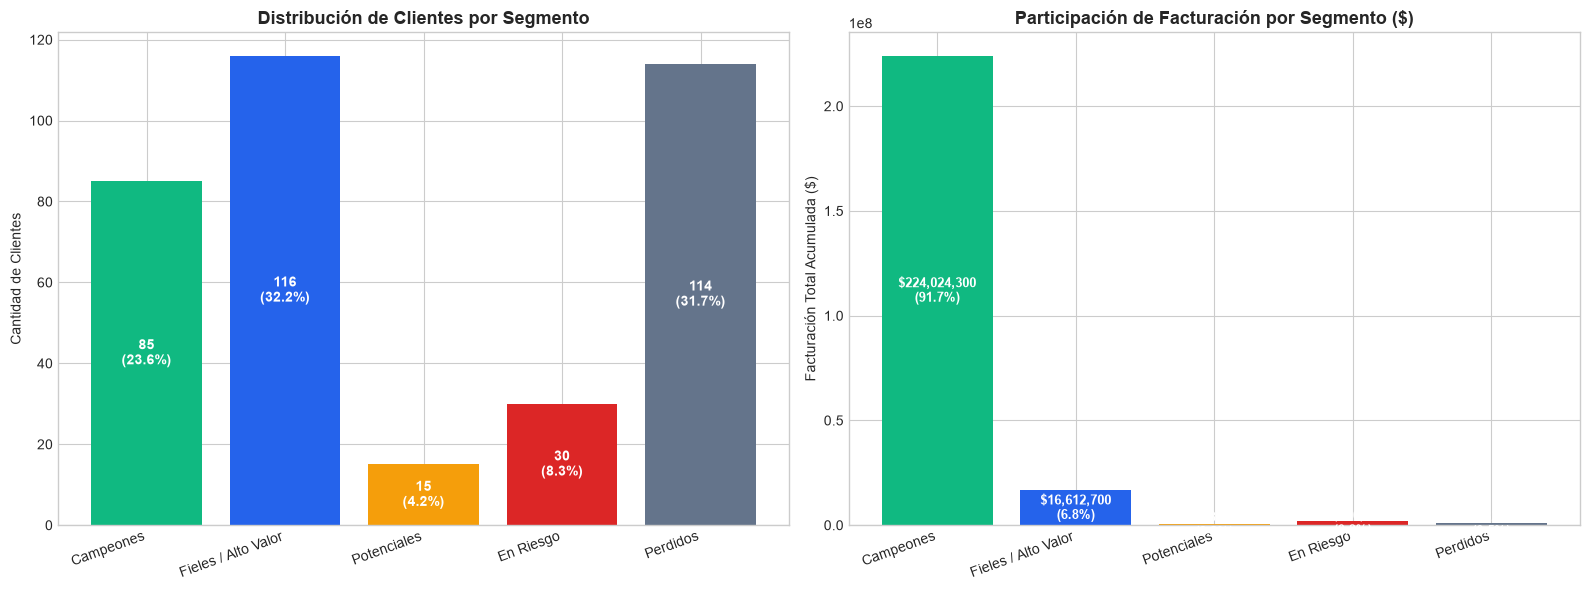

In [19]:
# 4.4.3 Visualización de la Segmentación RFM Oficial con Paleta Corporativa
segment_order = ['Campeones', 'Fieles / Alto Valor', 'Potenciales', 'En Riesgo', 'Perdidos']
segment_colors = {
    'Campeones': '#10B981',           # Verde esmeralda
    'Fieles / Alto Valor': '#2563EB', # Azul corporativo
    'Potenciales': '#F59E0B',         # Ámbar
    'En Riesgo': '#DC2626',           # Rojo alerta
    'Perdidos': '#64748B'             # Gris pizarra
}

conteo_segmentos = rfm_df['segmento'].value_counts().reindex(segment_order).fillna(0)
facturacion_segmentos = rfm_df.groupby('segmento')['valor_monetario'].sum().reindex(segment_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subgráfico 1: Cantidad de Clientes por Segmento
ax1 = axes[0]
bars1 = ax1.bar(segment_order, conteo_segmentos.values, color=[segment_colors[s] for s in segment_order])
for bar in bars1:
    y = bar.get_height()
    pct = (y / len(rfm_df)) * 100
    ax1.annotate(f"{int(y)}\n({pct:.1f}%)", (bar.get_x() + bar.get_width() / 2., y / 2),
                 ha='center', va='center', color='white', fontweight='bold')
ax1.set_title("Distribución de Clientes por Segmento", fontsize=13, fontweight='bold')
ax1.set_ylabel("Cantidad de Clientes")
ax1.set_xticklabels(segment_order, rotation=20, ha='right')

# Subgráfico 2: Facturación Acumulada por Segmento
ax2 = axes[1]
bars2 = ax2.bar(segment_order, facturacion_segmentos.values, color=[segment_colors[s] for s in segment_order])
for bar in bars2:
    y = bar.get_height()
    pct = (y / facturacion_segmentos.sum()) * 100
    ax2.annotate(f"${y:,.0f}\n({pct:.1f}%)", (bar.get_x() + bar.get_width() / 2., y / 2),
                 ha='center', va='center', color='white', fontweight='bold', fontsize=9)
ax2.set_title("Participación de Facturación por Segmento ($)", fontsize=13, fontweight='bold')
ax2.set_ylabel("Facturación Total Acumulada ($)")
ax2.set_xticklabels(segment_order, rotation=20, ha='right')

plt.tight_layout()
plt.show()

In [20]:
# 4.4.4 Listado Prioritario de Contactos Urgentes (Cuentas en Riesgo de Fuga)
# Filtramos las cuentas clasificadas en 'En Riesgo'
cuentas_en_riesgo = rfm_df[rfm_df['segmento'] == 'En Riesgo'].sort_values('valor_monetario', ascending=False).copy()

# Enriquecemos con prioridad comercial y acción sugerida
cuentas_en_riesgo['prioridad'] = np.where(
    cuentas_en_riesgo['valor_monetario'] >= cuentas_en_riesgo['valor_monetario'].median(),
    'Crítico - Alta Exposición',
    'Alto Riesgo'
)
cuentas_en_riesgo['accion_comercial'] = np.where(
    cuentas_en_riesgo['prioridad'] == 'Crítico - Alta Exposición',
    'Llamada comercial inmediata + Descuento por lote en pre-campaña',
    'Relevamiento telefónico de intención de siembra y propuesta técnica'
)

print(f"🚨 ALERTA COMERCIAL: Se detectaron {len(cuentas_en_riesgo)} cuentas en RIESGO CRÍTICO.")
print(f"Capital histórico acumulado expuesto en este segmento: ${cuentas_en_riesgo['valor_monetario'].sum():,.2f}\n")

print("=== LISTADO DE CONTACTOS URGENTES (ORDENADO POR IMPACTO MONETARIO) ===")
display(cuentas_en_riesgo[['id_cliente', 'recencia', 'frecuencia', 'valor_monetario', 'score_rfm', 'prioridad', 'accion_comercial']].head(15))

🚨 ALERTA COMERCIAL: Se detectaron 30 cuentas en RIESGO CRÍTICO.
Capital histórico acumulado expuesto en este segmento: $2,016,500.00

=== LISTADO DE CONTACTOS URGENTES (ORDENADO POR IMPACTO MONETARIO) ===


,id_cliente,recencia,frecuencia,valor_monetario,score_rfm,prioridad,accion_comercial
38,760,1121,75,412400.00,255,Crítico - Alta Exposición,Llamada comercial inmediata + Descuento por lo...
241,4797,1057,42,314400.00,255,Crítico - Alta Exposición,Llamada comercial inmediata + Descuento por lo...
4,33,1058,5,113000.00,234,Crítico - Alta Exposición,Llamada comercial inmediata + Descuento por lo...
100,2065,1053,15,109000.00,254,Crítico - Alta Exposición,Llamada comercial inmediata + Descuento por lo...
0,3,1129,10,99800.00,243,Crítico - Alta Exposición,Llamada comercial inmediata + Descuento por lo...
128,2736,1529,23,98900.00,253,Crítico - Alta Exposición,Llamada comercial inmediata + Descuento por lo...
151,3276,1058,18,89100.00,253,Crítico - Alta Exposición,Llamada comercial inmediata + Descuento por lo...
5,37,1117,9,85700.00,243,Crítico - Alta Exposición,Llamada comercial inmediata + Descuento por lo...
84,1779,1242,22,83900.00,253,Crítico - Alta Exposición,Llamada comercial inmediata + Descuento por lo...
212,4673,1291,11,61050.00,243,Crítico - Alta Exposición,Llamada comercial inmediata + Descuento por lo...


## Fase 5: Evaluación y Conclusiones del Negocio (Evaluation)

### 5.1. Validación de Hipótesis y Preguntas Iniciales
1. **Concentración de Facturación y Demanda:**  
   Se confirma plenamente el principio de Pareto: más del 80% de la facturación proviene de un grupo reducido de clientes clave, y la demanda operativa está fuertemente polarizada en **Soja, Trigo y Maíz**.
2. **Estacionalidad y Capacidad Operativa:**  
   La demanda presenta un patrón bi-estacional muy marcado:
   - Pico Otoño-Invernal (Abril - Julio): Dominado por Soja y análisis de cosecha gruesa.
   - Pico Primavera-Veraniego (Octubre - Enero): Dominado por Trigo y ensayos de poder germinativo de cara a la siembra.
   - La planificación de personal técnico e insumos debe dimensionarse utilizando los percentiles **P75** y **P90**, evitando el sesgo a la baja que produce la media simple.
3. **Fidelización y Prevención Activa de Fuga:**  
   La segmentación RFM permite identificar de manera proactiva qué cuentas históricas de gran valor están sufriendo caídas severas de recencia. El **Listado de Contactos Urgentes** constituye la herramienta operativa directa para el equipo comercial antes del inicio de cada campaña.

### 5.2. Protocolo de Mitigación Activa de Deserción
Para capitalizar estos hallazgos analíticos, se recomienda un protocolo en tres niveles:
1. **Nivel 1 (Cuentas Críticas):** Contacto directo por la gerencia comercial a cuentas con impacto monetario en el cuartil superior antes de transcurridos 60 días de inactividad en su cultivo predominante.
2. **Nivel 2 (Campañas de Reactivación Pre-Campaña):** Lanzamiento de paquetes de análisis bonificados (ej. Poder Germinativo + Vigor) 45 días antes de los picos históricos de siembra de Trigo y Soja.
3. **Nivel 3 (Monitoreo Continuo en Producción):** Despliegue del dashboard interactivo en Streamlit conectado a la base depurada de 8.149 registros, permitiendo a los directores del laboratorio explorar filtros por fechas, especies y quintiles en tiempo real.

---
*Notebook generado y validado conforme al estándar CRISP-DM y las especificaciones de las Historias de Usuario HU-01, HU-02 y HU-03.*